# EdgeAI-ZU4EV — Phase 1B: QKeras 6-bit QAT

**Prerequisite**: Run `cifar10_train.ipynb` first (`model_fp32.h5`, `model_teacher.h5`).

**Goal**: 6-bit QAT on VGG-Lite student (16/24/32) with **KD + MixUp/CutMix + EMA + SGD-Cosine**,  
export `model_int8_qkeras.h5` for hls4ml (RF=64).

**Install**: `pip install qkeras tensorflow==2.6.0`

---

## 1. Imports & Setup

In [1]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# QKeras — quantization-aware training library (compatible with hls4ml)
# Key quantizers used:
#   quantized_bits(bits, integer, keep_negative)
#     bits    : total bit width (including sign bit)
#     integer : number of bits for integer part
#     keep_negative : 1 = signed, 0 = unsigned
#   quantized_relu(bits, integer)
#     Same but forces non-negative (no sign bit needed)
from qkeras import (
    QActivation, QConv2D, QDense,
    quantized_bits, quantized_relu
)
from qkeras.utils import model_save_quantized_weights

# Required for keras.models.load_model / .save on .h5 (TF 2.6)
import h5py  # noqa: F401

Q_CUSTOM_OBJECTS = {
    'QConv2D': QConv2D,
    'QDense': QDense,
    'QActivation': QActivation,
    'quantized_bits': quantized_bits,
    'quantized_relu': quantized_relu,
}

def save_qkeras_h5(model, path):
    """Save full QKeras model for TF 2.6 + hls4ml."""
    model.save(path, include_optimizer=False)

def load_qkeras_h5(path):
    """Load .h5 QKeras model (TF 2.6; do not use before file exists)."""
    if not os.path.isfile(path):
        raise FileNotFoundError(
            f'{path} not found. Run the Q6 QAT training cell above first.'
        )
    return keras.models.load_model(
        path, custom_objects=Q_CUSTOM_OBJECTS, compile=False
    )

# val_ds uses y_test_ohe — same as cifar10_train.ipynb section 7
EVAL_COMPILE_KW = dict(
    optimizer=keras.optimizers.SGD(),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

def compile_for_eval(model):
    model.compile(**EVAL_COMPILE_KW)
    return model

tf.random.set_seed(42)
np.random.seed(42)

print(f'TensorFlow : {tf.__version__}')
print(f'h5py       : {h5py.__version__}')

os.makedirs('../results', exist_ok=True)

CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']
BATCH_SIZE = 128

TensorFlow : 2.6.0
h5py       : 3.1.0


## 2. Load Dataset

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0
y_train_ohe = keras.utils.to_categorical(y_train, 10)
y_test_ohe  = keras.utils.to_categorical(y_test,  10)

AUTOTUNE = tf.data.AUTOTUNE

def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.pad_to_bounding_box(image, 4, 4, 40, 40)
    image = tf.image.random_crop(image, size=[32, 32, 3])
    return image, label

train_ds = (
    tf.data.Dataset.from_tensor_slices((x_train, y_train_ohe))
    .shuffle(50000).map(augment, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE).prefetch(AUTOTUNE)
)
val_ds = (
    tf.data.Dataset.from_tensor_slices((x_test, y_test_ohe))
    .batch(BATCH_SIZE).prefetch(AUTOTUNE)
)
print('Dataset loaded.')

2026-05-21 11:52:11.399327: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:923] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-21 11:52:11.417709: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:923] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-21 11:52:11.418417: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:923] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-21 11:52:11.419013: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate

Dataset loaded.


## 3. Model Builders — VGG-Lite (match `cifar10_train.ipynb`)

| Variant | Architecture | Quantization |
|---------|--------------|--------------|
| FP32 reference | 16/20/24 double-conv + GAP | None (load `model_fp32.h5`) |
| **Q6 deploy** | same topology (16/20/24) | `quantized_bits(6,0,alpha='auto_po2')` + `quantized_relu(6)` |

In [3]:
def _conv_block_q(x, filters, prefix, k_q, b_q, a_q):
    for suffix in ('a', 'b'):
        name = f'{prefix}{suffix}'
        x = QConv2D(filters, 3, padding='same', use_bias=False,
                    kernel_quantizer=k_q, bias_quantizer=b_q, name=name)(x)
        x = layers.BatchNormalization(name=f'bn_{name}')(x)
        x = QActivation(a_q, name=f'relu_{name}')(x)
    return x


def build_q6_student(name='VGG_Lite_Q6'):
    """16/20/24 channel student — matches cifar10_train.ipynb 16/20/24 topology."""
    k_q = quantized_bits(6, 0, alpha='auto_po2')
    b_q = quantized_bits(6, 2, alpha='auto_po2')
    a_q = quantized_relu(6)
    inp = keras.Input((32, 32, 3), name='input_image')
    x = _conv_block_q(inp, 16, 'conv1', k_q, b_q, a_q)
    x = layers.MaxPooling2D(2, name='pool1')(x)
    x = _conv_block_q(x, 20, 'conv2', k_q, b_q, a_q)
    x = layers.MaxPooling2D(2, name='pool2')(x)
    x = _conv_block_q(x, 24, 'conv3', k_q, b_q, a_q)
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    out = QDense(10, activation='softmax', kernel_quantizer=k_q, bias_quantizer=b_q, name='predictions')(x)
    return keras.Model(inp, out, name=name)


m_q6 = build_q6_student()
m_q6.summary()
print('Q6 parameters:', m_q6.count_params())



Model: "VGG_Lite_Q6"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_image (InputLayer)     [(None, 32, 32, 3)]       0         
_________________________________________________________________
conv1a (QConv2D)             (None, 32, 32, 16)        432       
_________________________________________________________________
bn_conv1a (BatchNormalizatio (None, 32, 32, 16)        64        
_________________________________________________________________
relu_conv1a (QActivation)    (None, 32, 32, 16)        0         
_________________________________________________________________
conv1b (QConv2D)             (None, 32, 32, 16)        2304      
_________________________________________________________________
bn_conv1b (BatchNormalizatio (None, 32, 32, 16)        64        
_________________________________________________________________
relu_conv1b (QActivation)    (None, 32, 32, 16)        

## 4. QAT Training Helpers (KD + MixUp/CutMix + EMA)


In [4]:
# QAT: KD + MixUp/CutMix + EMA + SGD-Cosine (inline, same as cifar10_train.ipynb)

class WarmupCosineDecay(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, initial_lr, steps_per_epoch, total_epochs, warmup_epochs=8, min_lr=5e-5):
        self.initial_lr, self.warmup_steps = float(initial_lr), int(warmup_epochs * steps_per_epoch)
        self.total_steps, self.min_lr = int(total_epochs * steps_per_epoch), float(min_lr)
    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warmup = self.initial_lr * step / tf.maximum(tf.cast(self.warmup_steps, tf.float32), 1.0)
        progress = tf.clip_by_value((step - tf.cast(self.warmup_steps, tf.float32)) /
            tf.maximum(tf.cast(self.total_steps - self.warmup_steps, tf.float32), 1.0), 0.0, 1.0)
        cosine = self.min_lr + 0.5 * (self.initial_lr - self.min_lr) * (1.0 + tf.cos(np.pi * progress))
        return tf.cond(step < tf.cast(self.warmup_steps, tf.float32), lambda: warmup, lambda: cosine)

def make_sgd_optimizer(steps_per_epoch, total_epochs, lr_init=0.03, min_lr=5e-5):
    return keras.optimizers.SGD(learning_rate=WarmupCosineDecay(lr_init, steps_per_epoch, total_epochs, warmup_epochs=8, min_lr=min_lr), momentum=0.9, nesterov=True)

def _sample_lam(alpha):
    return 1.0 if alpha <= 0 else float(np.random.beta(alpha, alpha))

def mixup_batch(x, y, alpha=0.2):
    lam = _sample_lam(alpha); idx = tf.random.shuffle(tf.range(tf.shape(x)[0]))
    return lam * x + (1.0 - lam) * tf.gather(x, idx), lam * y + (1.0 - lam) * tf.gather(y, idx)

def cutmix_batch(x, y, alpha=1.0):
    lam = _sample_lam(alpha); idx = tf.random.shuffle(tf.range(tf.shape(x)[0]))
    x2, y2 = tf.gather(x, idx), tf.gather(y, idx)
    h, w = tf.shape(x)[1], tf.shape(x)[2]
    cut_h = tf.cast(tf.cast(h, tf.float32) * tf.sqrt(1.0 - lam), tf.int32)
    cut_w = tf.cast(tf.cast(w, tf.float32) * tf.sqrt(1.0 - lam), tf.int32)
    cy = tf.random.uniform([], 0, h - cut_h + 1, dtype=tf.int32)
    cx = tf.random.uniform([], 0, w - cut_w + 1, dtype=tf.int32)
    yy, xx = tf.reshape(tf.range(h), [h, 1, 1]), tf.reshape(tf.range(w), [1, w, 1])
    inside = tf.cast((yy >= cy) & (yy < cy + cut_h) & (xx >= cx) & (xx < cx + cut_w), x.dtype)
    x_mix = x * (1.0 - inside) + x2 * inside
    lam_adj = 1.0 - tf.cast(cut_h * cut_w, tf.float32) / (tf.cast(h, tf.float32) * tf.cast(w, tf.float32))
    return x_mix, lam_adj * y + (1.0 - lam_adj) * y2

def augment_batch(x, y, mixup_alpha=0.2, cutmix_alpha=1.0):
    return mixup_batch(x, y, mixup_alpha) if mixup_alpha > 0 and tf.random.uniform([]) < 0.5 else cutmix_batch(x, y, cutmix_alpha)

class ModelEMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = [tf.Variable(w, trainable=False) for w in model.trainable_weights]
    def update(self, model):
        for s, w in zip(self.shadow, model.trainable_weights):
            s.assign(self.decay * s + (1.0 - self.decay) * w)
    def apply_weights(self, model):
        self.backup = [tf.identity(w) for w in model.trainable_weights]
        for s, w in zip(self.shadow, model.trainable_weights): w.assign(s)
    def restore_weights(self, model):
        for w, b in zip(model.trainable_weights, self.backup): w.assign(b)

def label_smooth(y, smoothing=0.1, n_classes=10):
    y = tf.cast(y, tf.float32)
    return y * (1.0 - smoothing) + smoothing / float(n_classes)

def kd_loss_fn(s_logits, t_logits, y_true, alpha, temperature, label_smoothing):
    y_ls = label_smooth(y_true, label_smoothing)
    ce = tf.reduce_mean(tf.keras.losses.categorical_crossentropy(y_ls, s_logits))
    t_soft = tf.nn.softmax(t_logits / temperature, axis=-1)
    s_soft = tf.nn.softmax(s_logits / temperature, axis=-1)
    kd = tf.reduce_mean(tf.keras.losses.KLDivergence()(t_soft, s_soft)) * (temperature ** 2)
    return alpha * kd + (1.0 - alpha) * ce

def train_q6_qat(student, teacher, train_ds, val_ds, epochs=220, save_path='model_int8_qkeras.h5',
                 fp32_weights='model_fp32.h5', kd_alpha=0.75, kd_temp=3.5, kd_start=5):
    if os.path.isfile(fp32_weights):
        student.load_weights(fp32_weights, by_name=True, skip_mismatch=True)
        print('  Loaded FP32 init from', fp32_weights)
    teacher.trainable = False
    opt = make_sgd_optimizer(len(train_ds), epochs, lr_init=0.03)
    ema = ModelEMA(student)
    best_ema = 0.0
    for epoch in range(epochs):
        alpha_kd = kd_alpha if epoch >= kd_start else 0.0
        for xb, yb in train_ds:
            x_aug, y_aug = augment_batch(xb, yb)
            with tf.GradientTape() as tape:
                loss = kd_loss_fn(student(x_aug, True), teacher(x_aug, False), y_aug, alpha_kd, kd_temp, 0.1)
            opt.apply_gradients(zip(tape.gradient(loss, student.trainable_variables), student.trainable_variables))
            ema.update(student)
        ema_accs = []
        ema.apply_weights(student)
        for xb, yb in val_ds:
            ema_accs.append(float(tf.reduce_mean(tf.cast(
                tf.equal(tf.argmax(yb, 1), tf.argmax(student(xb, False), 1)), tf.float32))))
        ema.restore_weights(student)
        ema_val = float(np.mean(ema_accs))
        if (epoch + 1) % 10 == 0:
            print(f'  QAT ep {epoch+1}/{epochs} ema_val={ema_val:.4f}')
        if ema_val > best_ema:
            best_ema = ema_val
            ema.apply_weights(student)
            save_qkeras_h5(student, save_path)
            ema.restore_weights(student)
    print('  Best Q6 EMA val:', best_ema)
    return best_ema

print('QAT training helpers ready.')



QAT training helpers ready.


## 5. Q6 QAT Training & Evaluation


In [5]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("Is GPU available: ", tf.test.is_gpu_available())

Num GPUs Available:  1
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


Is GPU available:  True


2026-05-21 11:52:17.111286: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:923] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-21 11:52:17.112123: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:923] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-21 11:52:17.112844: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:923] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-21 11:52:17.113852: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:923] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-21 11:52:17.113863: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1594] Could not ident

In [6]:
# (Optional) after Q6 training:
# m_test = load_qkeras_h5('model_int8_qkeras.h5')
# m_test.summary()
print('Run section 5: Q6 QAT (requires model_fp32.h5 + model_teacher.h5 from Phase 1A).')

Run section 5: Q6 QAT (requires model_fp32.h5 + model_teacher.h5 from Phase 1A).


In [7]:
results = {}

print('=== FP32 Student (from cifar10_train.ipynb) ===')
if not os.path.isfile('model_fp32.h5'):
    raise FileNotFoundError('Run cifar10_train.ipynb first')
if not os.path.isfile('model_teacher.h5'):
    raise FileNotFoundError('Run cifar10_train.ipynb first (model_teacher.h5)')

m_fp32 = compile_for_eval(keras.models.load_model('model_fp32.h5'))
teacher = compile_for_eval(keras.models.load_model('model_teacher.h5'))
_, acc_fp32 = m_fp32.evaluate(val_ds, verbose=0)
results['FP32'] = {'accuracy': acc_fp32, 'size_kb': os.path.getsize('model_fp32.h5')/1024}
print(f'  FP32: {acc_fp32*100:.2f}%')
if acc_fp32 < 0.83:
    print(f'  WARNING: FP32 {acc_fp32*100:.2f}% < 83% — consider more epochs in Phase 1A')

print()
print('=== Q6 QAT (KD + MixUp/CutMix + EMA) ===')
m_q6 = build_q6_student()
train_q6_qat(m_q6, teacher, train_ds, val_ds, epochs=220, kd_alpha=0.75, kd_temp=3.5)
m_q6 = compile_for_eval(load_qkeras_h5('model_int8_qkeras.h5'))
_, acc_q6 = m_q6.evaluate(val_ds, verbose=0)
results['Q6'] = {'accuracy': acc_q6, 'size_kb': os.path.getsize('model_int8_qkeras.h5')/1024}
print(f'  Q6: {acc_q6*100:.2f}%')
if acc_q6 < 0.83:
    print(f'  WARNING: Q6 {acc_q6*100:.2f}% < 83% — may still proceed to hls4ml for resource check')



=== FP32 Student (from cifar10_train.ipynb) ===


2026-05-21 11:52:17.537963: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)
2026-05-21 11:52:18.507740: I tensorflow/stream_executor/cuda/cuda_dnn.cc:369] Loaded cuDNN version 8100
2026-05-21 11:52:19.960710: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-05-21 11:52:19.961639: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-05-21 11:52:19.961680: W tensorflow/stream_executor/gpu/asm_compiler.cc:77] Couldn't get ptxas version string: Internal: Couldn't invoke ptxas --version
2026-05-21 11:52:19.962731: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-05-21 11:52:19.962825: W tensorflow/stream_executor/gpu/redzone_allocator.cc:314] Internal: Failed to launch ptxas
Relying on driver to perform ptx co

  FP32: 81.05%

=== Q6 QAT (KD + MixUp/CutMix + EMA) ===
  Loaded FP32 init from model_fp32.h5


2026-05-21 11:52:22.188184: W tensorflow/core/framework/cpu_allocator_impl.cc:80] Allocation of 614400000 exceeds 10% of free system memory.


2026-05-21 11:52:57.736068: W tensorflow/core/framework/cpu_allocator_impl.cc:80] Allocation of 614400000 exceeds 10% of free system memory.
2026-05-21 11:53:31.772823: W tensorflow/core/framework/cpu_allocator_impl.cc:80] Allocation of 614400000 exceeds 10% of free system memory.


...

  QAT ep 90/220 ema_val=0.7787
  QAT ep 100/220 ema_val=0.7747


  QAT ep 110/220 ema_val=0.7826
  QAT ep 120/220 ema_val=0.7676


  QAT ep 130/220 ema_val=0.7878


  QAT ep 140/220 ema_val=0.7849
  QAT ep 150/220 ema_val=0.7904


  QAT ep 160/220 ema_val=0.7891
  QAT ep 170/220 ema_val=0.7902
  QAT ep 180/220 ema_val=0.7911
  QAT ep 190/220 ema_val=0.7888
  QAT ep 200/220 ema_val=0.7923
  QAT ep 210/220 ema_val=0.7936
  QAT ep 220/220 ema_val=0.7908
  Best Q6 EMA val: 0.7958860759493671
  Q6: 79.43%


## 6. Accuracy & Size Comparison Table

Quantization Comparison:
Variant Accuracy (%) Model Size (KB) Accuracy Drop (pp)
   FP32        81.05           141.7               0.00
     Q6        79.43           146.5               1.62


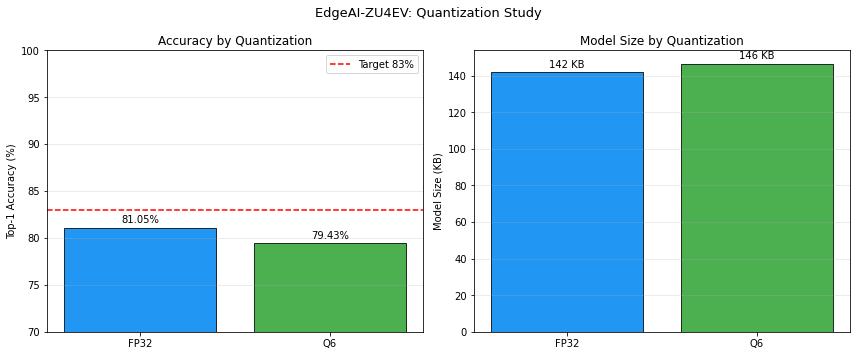

Saved: ../results/quantization_comparison.png

→ model_int8_qkeras.h5 is ready for Phase 1C (hls4ml synthesis)


In [8]:
df = pd.DataFrame([
    {'Variant': k,
     'Accuracy (%)': f"{v['accuracy']*100:.2f}",
     'Model Size (KB)': f"{v['size_kb']:.1f}",
     'Accuracy Drop (pp)': f"{(results['FP32']['accuracy']-v['accuracy'])*100:.2f}"}
    for k, v in results.items()
])

print('Quantization Comparison:')
print(df.to_string(index=False))

df.to_csv('../results/quantization_comparison.csv', index=False)

# Bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

variants = list(results.keys())
accs     = [results[v]['accuracy']*100 for v in variants]
sizes    = [results[v]['size_kb']      for v in variants]
colors   = ['#2196F3', '#4CAF50'][:len(variants)]

bars = ax1.bar(variants, accs, color=colors, edgecolor='black', linewidth=0.8)
for bar in bars:
    height = bar.get_height()
    ax1.annotate(f'{height:.2f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom')
ax1.axhline(83, color='red', linestyle='--', label='Target 83%')
ax1.set_ylabel('Top-1 Accuracy (%)')
ax1.set_title('Accuracy by Quantization')
ax1.set_ylim([70, 100])
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

bars2 = ax2.bar(variants, sizes, color=colors, edgecolor='black', linewidth=0.8)
for bar in bars2:
    height = bar.get_height()
    ax2.annotate(f'{height:.0f} KB',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')
ax2.set_ylabel('Model Size (KB)')
ax2.set_title('Model Size by Quantization')
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('EdgeAI-ZU4EV: Quantization Study', fontsize=13)
plt.tight_layout()
plt.savefig('../results/quantization_comparison.png', dpi=150)
plt.show()

print('Saved: ../results/quantization_comparison.png')
print('\n→ model_int8_qkeras.h5 is ready for Phase 1C (hls4ml synthesis)')